# Практическое задание 2. Нейронные сети
1. Загрузка и подготовка MNIST

In [11]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Загружаем MNIST
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Нормализация
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Добавляем размерность канала: (28, 28) - (28, 28, 1)
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train: (60000, 28, 28, 1)
x_test: (10000, 28, 28, 1)


2. Создание сверточной модели

In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),

    tf.keras.layers.Conv2D(32, (3, 3), padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Conv2D(32, (3, 3), padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    # _____________
    tf.keras.layers.Conv2D(64, (3, 3), padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.Conv2D(64, (3, 3), padding="same", use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),

    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    # Классификатор
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, use_bias=False),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10)  # 10 классов, логиты
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 468,778 (1.79 MB)

 Trainable params: 468,138 (1.79 MB)

 Non-trainable params: 640 (2.50 KB)

3. Компиляция и обучение

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    callbacks=callbacks
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.9313 - loss: 0.2392 - val_accuracy: 0.7468 - val_loss: 0.7370 - learning_rate: 0.0010
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9782 - loss: 0.0759 - val_accuracy: 0.9902 - val_loss: 0.0304 - learning_rate: 0.0010
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9837 - loss: 0.0554 - val_accuracy: 0.9912 - val_loss: 0.0283 - learning_rate: 0.0010
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9854 - loss: 0.0481 - val_accuracy: 0.9913 - val_loss: 0.0284 - learning_rate: 0.0010
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9884 - loss: 0.0397 - val_accuracy: 0.9910 - val_loss: 0.0287 - learning_rate: 0.0010
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9909 - loss: 0.0301 - val_accuracy: 0.9923 - val_loss: 0.0239 - learning_rate: 5.0000e-04
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9916 - los

4. Проверка точности

In [14]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Точность на тесте: {test_acc:.4f} ({test_acc * 100:.2f}%)")

313/313 - 3s - 9ms/step - accuracy: 0.9961 - loss: 0.0131
Точность на тесте: 0.9961 (99.61%)


5. Таблица результатов

,Реальная цифра,Распознано моделью,Вероятность
0,7,7,100.00%
1,2,2,100.00%
2,1,1,100.00%
3,0,0,100.00%
4,4,4,100.00%
5,1,1,100.00%
6,4,4,99.99%
7,9,9,100.00%
8,5,5,99.14%
9,9,9,100.00%


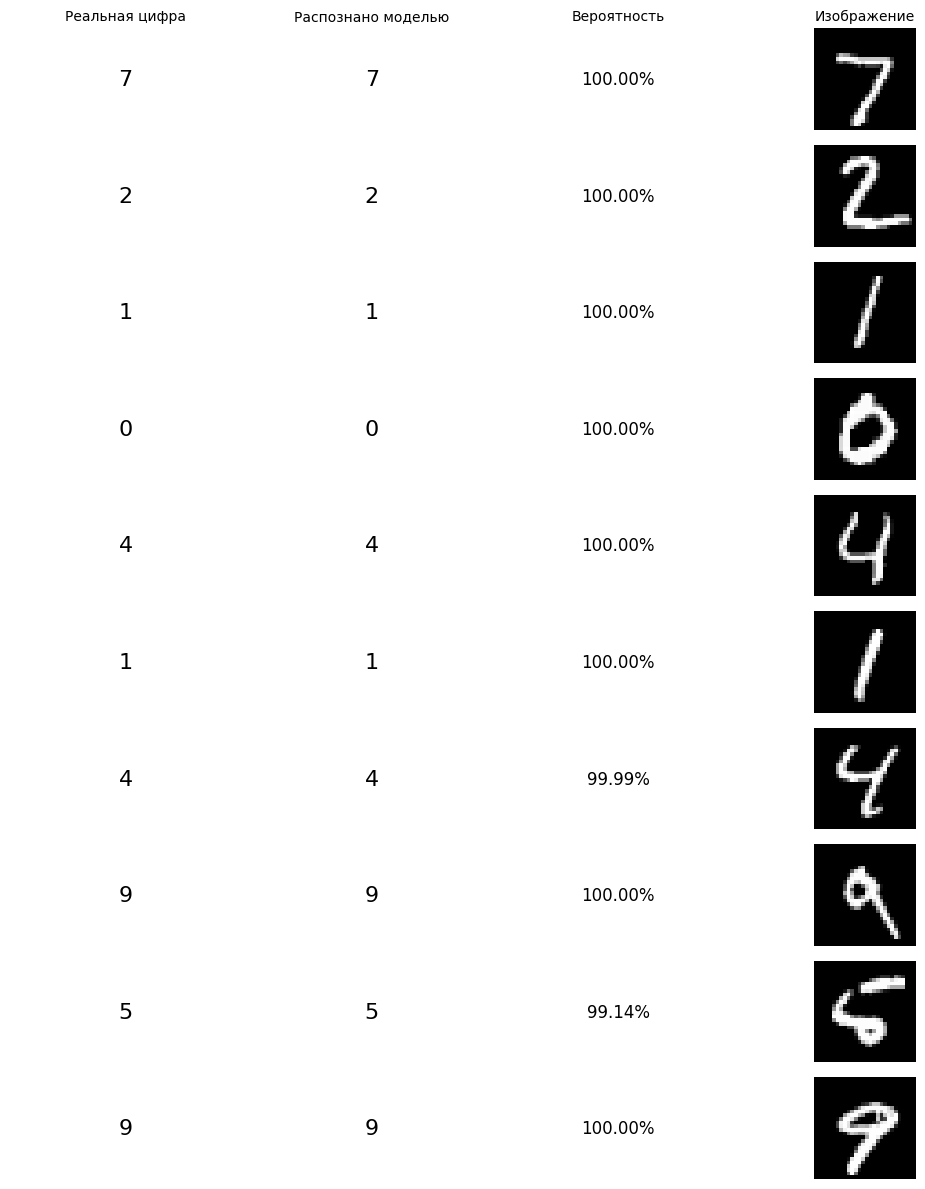

In [15]:
# Модель, возвращающая вероятности
probability_model = tf.keras.Sequential([
    model,
    tf.keras.layers.Softmax()
])

N = 10
images = x_test[:N]          # (10, 28, 28, 1)
true_digits = y_test[:N]

probs = probability_model(images).numpy()
pred_digits = np.argmax(probs, axis=1)
confidences = np.max(probs, axis=1)

# Текстовая таблица
df = pd.DataFrame({
    "Реальная цифра": true_digits,
    "Распознано моделью": pred_digits,
    "Вероятность": [f"{c:.2%}" for c in confidences]
})

display(df)  # В Colab работает; если нет — print(df)

# Таблица с изображениями
fig, axes = plt.subplots(N, 4, figsize=(10, 12))
headers = ["Реальная цифра", "Распознано моделью", "Вероятность", "Изображение"]

for j, h in enumerate(headers):
    axes[0, j].set_title(h, fontsize=10)

for i in range(N):
    axes[i, 0].text(0.5, 0.5, str(true_digits[i]),
                    ha="center", va="center", fontsize=16)
    axes[i, 0].axis("off")

    axes[i, 1].text(0.5, 0.5, str(pred_digits[i]),
                    ha="center", va="center", fontsize=16)
    axes[i, 1].axis("off")

    axes[i, 2].text(0.5, 0.5, f"{confidences[i]:.2%}",
                    ha="center", va="center", fontsize=12)
    axes[i, 2].axis("off")

    axes[i, 3].imshow(images[i].reshape(28, 28), cmap="gray")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()